In [10]:
#Setup & Reproducibility
import pandas as pd
import numpy as np
import pandas as pd
import mlflow
import mlflow.lightgbm
import mlflow.catboost
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve
from scipy.optimize import minimize
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
import pickle
import os

SEED = 42
np.random.seed(SEED)

In [11]:
train = pd.read_csv("../data/train.csv", sep=",", engine="python")
test = pd.read_csv("../data/test.csv", sep=",", engine="python")

In [12]:
train.shape,test.shape

((200000, 202), (200000, 201))

In [13]:
# -------------------------------
# 0️⃣ Keep original safe
# -------------------------------
train_orig = train.copy()
test_orig = test.copy()
train = train_orig.copy()
test = test_orig.copy()

In [14]:

# -------------------------------
# 1️⃣ Feature Engineering: Row stats + Frequency encoding
# -------------------------------
features = [c for c in train.columns if 'var' in c]

for df in [train, test]:
    df['row_mean'] = df[features].mean(axis=1)
    df['row_std']  = df[features].std(axis=1)
    df['row_min']  = df[features].min(axis=1)
    df['row_max']  = df[features].max(axis=1)
    df['row_sum']  = df[features].sum(axis=1)

features += ['row_mean','row_std','row_min','row_max','row_sum']

for col in [c for c in train.columns if 'var' in c]:
    freq = train[col].value_counts(normalize=True)
    train[col+'_freq'] = train[col].map(freq)
    test[col+'_freq'] = test[col].map(freq).fillna(0)
    features.append(col+'_freq')

features = list(dict.fromkeys(features))
X_full = train[features]
y_full = train['target']
X_test = test[features]

C:\Users\anime\AppData\Local\Temp\ipykernel_10136\2069251177.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col+'_freq'] = train[col].map(freq)
C:\Users\anime\AppData\Local\Temp\ipykernel_10136\2069251177.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col+'_freq'] = train[col].map(freq)
C:\Users\anime\AppData\Local\Temp\ipykernel_10136\2069251177.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

In [8]:
# ==========================================================
# 🏆 Santander Optimized Pipeline: SHAP Interactions + Feature Pruning + Optuna + CV Ensemble + MLflow
# ==========================================================

import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
import mlflow
import mlflow.lightgbm
import mlflow.catboost
import optuna
from lightgbm import early_stopping

mlflow.set_experiment("santander_shap_optuna_pruned_pipeline")

def get_positive_shap(shap_output):
    if isinstance(shap_output, list):
        return shap_output[1]   # binary classifier → positive class
    return shap_output          # already array

with mlflow.start_run(run_name="optimized_shap_pruned_pipeline"):

    # -------------------------------
    # 1️⃣ Feature Engineering: Row stats + Frequency encoding
    # -------------------------------
    features = [c for c in train.columns if 'var' in c]

    for df in [train, test]:
        df['row_mean'] = df[features].mean(axis=1)
        df['row_std']  = df[features].std(axis=1)
        df['row_min']  = df[features].min(axis=1)
        df['row_max']  = df[features].max(axis=1)
        df['row_sum']  = df[features].sum(axis=1)

    features += ['row_mean','row_std','row_min','row_max','row_sum']

    for col in [c for c in train.columns if 'var' in c]:
        freq = train[col].value_counts(normalize=True)
        train[col+'_freq'] = train[col].map(freq)
        test[col+'_freq'] = test[col].map(freq).fillna(0)
        features.append(col+'_freq')

    features = list(dict.fromkeys(features))
    X_full = train[features]
    y_full = train['target']
    X_test = test[features]

    mlflow.log_param("n_features_after_encoding", len(features))

    # =========================
    # 2️⃣ Baseline Models for SHAP (production-ready)
    # =========================

    # Sample for SHAP (max 20k rows for memory efficiency)
    shap_sample_size = min(1000, len(X_full))
    X_shap_sample = X_full.sample(shap_sample_size, random_state=42)

    # Train baseline models on full dataset (not inside CV)
    baseline_lgb = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=-1,
        random_state=42,
        n_jobs=-1
    )
    baseline_lgb.fit(X_full, y_full)

    baseline_cat = CatBoostClassifier(
        iterations=200,
        learning_rate=0.03,
        depth=6,
        thread_count=-1,
        random_seed=42,
        verbose=False
    )
    baseline_cat.fit(X_full, y_full)

    # SHAP explainers on sampled dataset (production-ready)
    explainer_lgb = shap.TreeExplainer(baseline_lgb)
    explainer_cat = shap.TreeExplainer(baseline_cat)

    #shap_values_lgb = explainer_lgb.shap_values(X_shap_sample)[1]
    #shap_values_cat = explainer_cat.shap_values(X_shap_sample)[1]
    shap_values_lgb = get_positive_shap(explainer_lgb.shap_values(X_shap_sample))
    shap_values_cat = get_positive_shap(explainer_cat.shap_values(X_shap_sample))

    # Mean absolute SHAP importance
    mean_abs_shap_lgb = np.abs(shap_values_lgb).mean(axis=0)
    mean_abs_shap_cat = np.abs(shap_values_cat).mean(axis=0)

    shap_importance = pd.DataFrame({
        'feature': X_shap_sample.columns,
        'lgb_importance': mean_abs_shap_lgb,
        'cat_importance': mean_abs_shap_cat
    })
    shap_importance['combined'] = 0.5*shap_importance['lgb_importance'] + 0.5*shap_importance['cat_importance']
    shap_importance = shap_importance.sort_values('combined', ascending=False)

    # Save explainer and SHAP values for production dashboards or local explanations
    import joblib
    import os

    os.makedirs("experiments", exist_ok=True)
    joblib.dump((explainer_lgb, explainer_cat, X_shap_sample), "experiments/shap_explainer_sampled.pkl")
    mlflow.log_artifact("experiments/shap_explainer_sampled.pkl")

    # -------------------------------
    # 3️⃣ Top 10 features for SHAP interactions (SAFE VERSION)
    # -------------------------------

    top_feats = shap_importance['feature'].head(10).tolist()

    # Sample FULL feature space (model requires all features)
    interaction_sample_full = X_full.sample(
        min(2000, len(X_full)),
        random_state=42
    )

    # Compute SHAP on full feature set
    shap_vals_full = get_positive_shap(
        explainer_lgb.shap_values(interaction_sample_full)
    )

    # Get indices of top features
    top_indices = [
        list(X_full.columns).index(f) 
        for f in top_feats
    ]

    # Extract SHAP values only for top features
    shap_vals_sample = shap_vals_full[:, top_indices]

    # Approximate interaction strength via SHAP correlation
    pairs = []
    for i, j in combinations(range(len(top_feats)), 2):
        f1 = top_feats[i]
        f2 = top_feats[j]

        corr = np.abs(
            np.corrcoef(shap_vals_sample[:, i], shap_vals_sample[:, j])[0, 1]
        )

        pairs.append((f1, f2, corr))

    # Select top 25 strongest interactions
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:25]
    interaction_pairs = [(f1, f2) for f1, f2, _ in pairs]

    # Create interaction features
    for f1, f2 in interaction_pairs:
        for df in [train, test]:
            df[f'{f1}_x_{f2}'] = df[f1] * df[f2]
            df[f'{f1}_ratio_{f2}'] = df[f1] / (df[f2] + 1e-5)
            features.extend([f'{f1}_x_{f2}', f'{f1}_ratio_{f2}'])

    features = list(dict.fromkeys(features))
    X_full = train[features]
    X_test = test[features]

    # -------------------------------
    # 4️⃣ SHAP + LGB Gain Feature Pruning (top N features)
    # -------------------------------
    # Train LGB on full data
    lgb_full = lgb.LGBMClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    lgb_full.fit(X_full, y_full)
    lgb_gain = lgb_full.booster_.feature_importance(importance_type="gain")

    # Train CatBoost for SHAP
    cat_full = CatBoostClassifier(iterations=150, verbose=False, thread_count=-1)
    cat_full.fit(X_full, y_full)

    sample = X_full.sample(min(1000, len(X_full)), random_state=42)
    explainer_cat = shap.TreeExplainer(cat_full)
    #cat_shap_vals = explainer_cat.shap_values(sample)[1]
    cat_shap_vals = get_positive_shap(explainer_cat.shap_values(sample))
    cat_shap = np.abs(cat_shap_vals).mean(axis=0)

    importance_df = pd.DataFrame({
        'feature': X_full.columns,
        'lgb_gain': lgb_gain,
        'cat_shap': cat_shap
    })
    importance_df['lgb_norm'] = importance_df['lgb_gain']/importance_df['lgb_gain'].sum()
    importance_df['cat_norm'] = importance_df['cat_shap']/importance_df['cat_shap'].sum()
    importance_df['combined'] = 0.5*importance_df['lgb_norm'] + 0.5*importance_df['cat_norm']

    # Keep top 85% features
    keep_ratio = 0.85
    top_n = int(len(importance_df)*keep_ratio)
    selected_features = importance_df.sort_values('combined', ascending=False).head(top_n)['feature'].tolist()

    X_full = X_full[selected_features]
    X_test = X_test[selected_features]
    mlflow.log_param("n_features_after_shap_pruning", len(selected_features))

    # -------------------------------
    # 5️⃣ Optuna Tuning - LightGBM
    # -------------------------------
    def lgb_objective(trial):
        params = {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
            "num_leaves": trial.suggest_int("num_leaves",16,128),
            "max_depth": trial.suggest_int("max_depth",3,12),
            "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0),
            "subsample": trial.suggest_float("subsample",0.6,1.0),
            "min_child_samples": trial.suggest_int("min_child_samples",5,100),
            "reg_alpha": trial.suggest_float("reg_alpha",0.0,5.0),
            "reg_lambda": trial.suggest_float("reg_lambda",0.0,5.0),
            "verbosity":-1
        }
        aucs=[]
        skf=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        with mlflow.start_run(nested=True):
            mlflow.log_params(params)
            for fold,(tr_idx,val_idx) in enumerate(skf.split(X_full,y_full)):
                model = lgb.LGBMClassifier(**params,n_estimators=300,n_jobs=-1)
                model.fit(X_full.iloc[tr_idx],y_full.iloc[tr_idx],
                          eval_set=[(X_full.iloc[val_idx],y_full.iloc[val_idx])],
                          eval_metric="auc",
                          callbacks=[early_stopping(30)])
                preds=model.predict_proba(X_full.iloc[val_idx])[:,1]
                aucs.append(roc_auc_score(y_full.iloc[val_idx],preds))
                mlflow.log_metric(f"fold_auc_{fold+1}",aucs[-1])
            mlflow.log_metric("trial_mean_auc",np.mean(aucs))
        return np.mean(aucs)

    #study_lgb = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
    study_lgb = optuna.create_study(
    study_name="lgb_optuna_study",
    direction="maximize",
    storage="sqlite:///optuna_lgb.db",
    load_if_exists=True
    )
    study_lgb.optimize(lgb_objective, n_trials=2)
    best_lgb_params = study_lgb.best_trial.params
    mlflow.log_params({f"lgb_{k}": v for k, v in best_lgb_params.items()})
    mlflow.log_metric("best_lgb_auc",study_lgb.best_value)

    # -------------------------------
    # 6️⃣ Optuna Tuning - CatBoost
    # -------------------------------
    def cat_objective(trial):
        params={
            "iterations":300,
            "learning_rate":trial.suggest_float("learning_rate",0.005,0.05,log=True),
            "depth":trial.suggest_int("depth",4,10),
            "l2_leaf_reg":trial.suggest_float("l2_leaf_reg",1,10),
            "bagging_temperature":trial.suggest_float("bagging_temperature",0,1),
            "random_seed":42,
            "eval_metric":"AUC",
            "verbose":False
        }
        aucs=[]
        skf=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        with mlflow.start_run(nested=True):
            mlflow.log_params(params)
            for fold,(tr_idx,val_idx) in enumerate(skf.split(X_full,y_full)):
                model=CatBoostClassifier(**params)
                model.fit(X_full.iloc[tr_idx],y_full.iloc[tr_idx],
                          eval_set=(X_full.iloc[val_idx],y_full.iloc[val_idx]),
                          early_stopping_rounds=50,
                          use_best_model=True)
                preds=model.predict_proba(X_full.iloc[val_idx])[:,1]
                aucs.append(roc_auc_score(y_full.iloc[val_idx],preds))
            mlflow.log_metric("trial_mean_auc",np.mean(aucs))
        return np.mean(aucs)

    #study_cat=optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
    study_cat = optuna.create_study(
    study_name="cat_optuna_study",
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(),
    storage="sqlite:///optuna_cat.db",
    load_if_exists=True
    )
    study_cat.optimize(cat_objective,n_trials=2)
    best_cat_params = study_cat.best_trial.params
    mlflow.log_params({f"cat_{k}": v for k, v in best_cat_params.items()})
    mlflow.log_metric("best_cat_auc",study_cat.best_value)

    # -------------------------------
    # 7️⃣ CV Ensemble + Weight optimization
    # -------------------------------
    skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
    oof_lgb=np.zeros(len(train))
    oof_cat=np.zeros(len(train))
    test_preds_lgb=np.zeros(len(test))
    test_preds_cat=np.zeros(len(test))

    #for fold,(tr_idx,val_idx) in enumerate(skf.split(X_full,y_full)):
    for fold, (tr_idx, val_idx) in enumerate(skf.split(train[selected_features], y_full)):
        lgb_model=lgb.LGBMClassifier(**best_lgb_params,n_estimators=1500,n_jobs=-1)
        lgb_model.fit(X_full.iloc[tr_idx],y_full.iloc[tr_idx])
        oof_lgb[val_idx]=lgb_model.predict_proba(X_full.iloc[val_idx])[:,1]
        test_preds_lgb+=lgb_model.predict_proba(X_test)[:,1]/skf.n_splits

        cat_model=CatBoostClassifier(**best_cat_params,iterations=1200,thread_count=-1,verbose=False)
        cat_model.fit(X_full.iloc[tr_idx],y_full.iloc[tr_idx])
        oof_cat[val_idx]=cat_model.predict_proba(X_full.iloc[val_idx])[:,1]
        test_preds_cat+=cat_model.predict_proba(X_test)[:,1]/skf.n_splits

    best_auc=0
    best_w=0
    for w in np.arange(0,1.05,0.05):
        ensemble=w*oof_lgb+(1-w)*oof_cat
        auc=roc_auc_score(y_full,ensemble)
        if auc>best_auc:
            best_auc=auc
            best_w=w

    oof_ens=best_w*oof_lgb+(1-best_w)*oof_cat
    test_preds_ens=best_w*test_preds_lgb+(1-best_w)*test_preds_cat
    mlflow.log_metric("best_weight",best_w)
    mlflow.log_metric("cv_auc",best_auc)

    # -------------------------------
    # 8️⃣ Thresholding
    # -------------------------------
    precisions, recalls, thresholds=precision_recall_curve(y_full,oof_ens)
    f1_scores=2*(precisions*recalls)/(precisions+recalls+1e-10)
    best_idx=f1_scores.argmax()
    best_threshold=thresholds[best_idx]
    y_pred_binary=(test_preds_ens>=best_threshold).astype(int)
    mlflow.log_metric("best_threshold",best_threshold)
    mlflow.log_metric("cv_f1_score",f1_scores[best_idx])

    # -------------------------------
    # 9️⃣ Final model training
    # -------------------------------
    lgb_final=lgb.LGBMClassifier(**best_lgb_params,n_estimators=500,n_jobs=-1)
    lgb_final.fit(X_full,y_full)
    cat_final=CatBoostClassifier(**best_cat_params,iterations=150,thread_count=-1,verbose=False)
    cat_final.fit(X_full,y_full)

    mlflow.lightgbm.log_model(lgb_final,"lightgbm_model")
    mlflow.catboost.log_model(cat_final,"catboost_model")

    # -------------------------------
    # 🔟 Prepare submission
    # -------------------------------
    submission=pd.DataFrame({
        'ID_code':test['ID_code'],
        'target_lgb':test_preds_lgb,
        'target_cat':test_preds_cat,
        'target_ensemble':test_preds_ens,
        'target_binary':y_pred_binary
    })
    submission.to_csv("santander_submission_final_pruned.csv",index=False)
    mlflow.log_artifact("santander_submission_final_pruned.csv")
    print("✅ Pipeline completed successfully")
    submission.head()

C:\Users\anime\AppData\Local\Temp\ipykernel_10136\3523868744.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col+'_freq'] = train[col].map(freq)
C:\Users\anime\AppData\Local\Temp\ipykernel_10136\3523868744.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col+'_freq'] = test[col].map(freq).fillna(0)
C:\Users\anime\AppData\Local\Temp\ipykernel_10136\3523868744.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's auc: 0.867823
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's auc: 0.861468
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's auc: 0.866348


[I 2026-03-05 12:23:55,434] Trial 2 finished with value: 0.8652131810911197 and parameters: {'learning_rate': 0.02819345351311852, 'num_leaves': 127, 'max_depth': 7, 'colsample_bytree': 0.7631873099886014, 'subsample': 0.9931082727437468, 'min_child_samples': 42, 'reg_alpha': 3.4935048215628903, 'reg_lambda': 4.805463539017679}. Best is trial 1 with value: 0.8723779153256187.


Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's auc: 0.830732
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's auc: 0.82446
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's auc: 0.827977


[I 2026-03-05 12:24:43,960] Trial 3 finished with value: 0.8277228352177511 and parameters: {'learning_rate': 0.012667154856614642, 'num_leaves': 35, 'max_depth': 6, 'colsample_bytree': 0.9422110369573702, 'subsample': 0.7950626431884315, 'min_child_samples': 28, 'reg_alpha': 2.8585022571938374, 'reg_lambda': 2.815661990715829}. Best is trial 1 with value: 0.8723779153256187.
[I 2026-03-05 12:24:44,007] Using an existing study with name 'cat_optuna_study' instead of creating a new one.
[I 2026-03-05 12:25:46,849] Trial 1 finished with value: 0.8646807414743578 and parameters: {'learning_rate': 0.04641587001645598, 'depth': 6, 'l2_leaf_reg': 4.343765229749317, 'bagging_temperature': 0.053946300391005564}. Best is trial 1 with value: 0.8646807414743578.
[I 2026-03-05 12:26:40,637] Trial 2 finished with value: 0.8504264125556271 and parameters: {'learning_rate': 0.03811855399421555, 'depth': 5, 'l2_leaf_reg': 2.1258644559740043, 'bagging_temperature': 0.716560135039496}. Best is trial 1 w

✅ Pipeline completed successfully


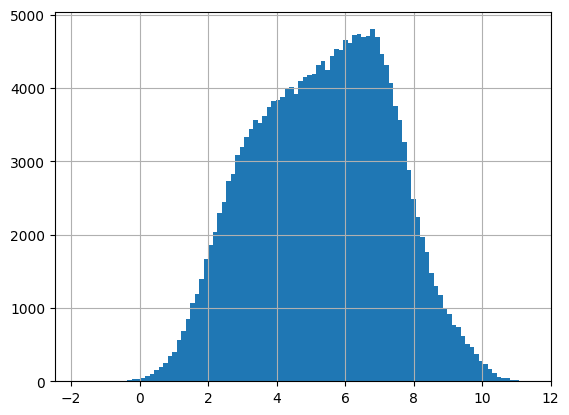

In [19]:
import matplotlib.pyplot as plt

train["var_78"].hist(bins=100)
plt.show()

<Axes: xlabel='unique_per_row', ylabel='Density'>

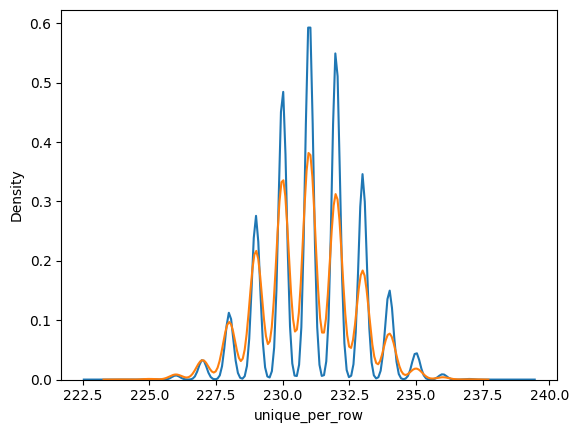

In [22]:
import seaborn as sns

sns.kdeplot(train[train.target==0]["unique_per_row"])
sns.kdeplot(train[train.target==1]["unique_per_row"])

In [23]:
train["var_78"].value_counts()

var_78
6.0926    15
6.7116    14
2.8648    14
4.3868    14
4.9666    13
          ..
8.4119     1
0.9170     1
1.6079     1
1.8880     1
1.8088     1
Name: count, Length: 72254, dtype: int64